In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Load dataset

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
test.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value
0,18001,2010-11-14 13:39:00,North,Social Media,Storage,Premium,16.50,1.65,0.2763,845.0,16185,0.0637,6.32,0.366025,30.0,4500.10
1,18002,2010-10-10 11:53:00,North,Affiliate,Storage,Premium,15.00,1.25,0.1694,525.0,5684,0.0213,2.75,-0.366025,21.0,15.00
2,18003,2010-10-31 11:06:00,North,Social Media,General,Premium,325.44,3.39,0.3736,362.0,11490,0.0070,0.58,-0.366025,NaN,1818.31
3,18004,2011-02-07 14:51:00,South,Social Media,General,Premium,7.80,0.65,0.3246,138.0,3046,0.0686,1.50,1.366025,7.0,4442.36
4,18005,2011-05-16 14:24:00,north,Search,General,Premium,458.00,4.58,0.2625,309.0,8983,0.0231,9.19,-0.366025,28.0,400409.80


## Exploratory Data Analysis (EDA)

### Understand the data

In [5]:
train.shape

(18000, 17)

In [6]:
train.columns

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

In [7]:
train.dtypes

id                           int64
date                        object
region                      object
channel                     object
product_category            object
customer_segment            object
ad_spend                   float64
price                      float64
discount_rate              float64
market_reach               float64
impressions                  int64
click_through_rate         float64
competition_index          float64
seasonality_index          float64
campaign_duration_days     float64
customer_lifetime_value    float64
sales_revenue              float64
dtype: object

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

In [9]:
train['date'] = pd.to_datetime(train['date'], format='mixed')

### Check null/missing values

In [10]:
train.isnull().sum()

id                            0
date                          0
region                        0
channel                       0
product_category              0
customer_segment              0
ad_spend                    658
price                         0
discount_rate               755
market_reach                686
impressions                   0
click_through_rate          713
competition_index           707
seasonality_index             0
campaign_duration_days     1513
customer_lifetime_value     743
sales_revenue                 0
dtype: int64

### Handling null / missing values

In [11]:
num_cols = train.select_dtypes(include=['int64','float64']).columns
cat_cols = train.select_dtypes(include=['object']).columns

for col in num_cols:
    train[col].fillna(train[col].median(), inplace=True)

for col in cat_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)

print(train.isnull().sum())

id                         0
date                       0
region                     0
channel                    0
product_category           0
customer_segment           0
ad_spend                   0
price                      0
discount_rate              0
market_reach               0
impressions                0
click_through_rate         0
competition_index          0
seasonality_index          0
campaign_duration_days     0
customer_lifetime_value    0
sales_revenue              0
dtype: int64


### Check Duplicates

In [12]:
train.duplicated().sum()

np.int64(0)

### Dataset summary

In [13]:
train.describe()

,id,date,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,18000.000000,18000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,9000.500000,2010-12-31 08:32:21.286666496,42.895739,5.648265,0.228952,319.396556,7257.423889,0.056600,3.998741,-0.014902,34.929667,9964.835959,137.204937
min,1.000000,2009-01-12 00:00:00,0.180000,0.040000,0.000200,1.000000,-30771.000000,0.000000,0.040000,-1.366025,7.000000,0.550000,0.000000
25%,4500.750000,2010-07-05 13:51:15,4.950000,1.250000,0.113200,142.000000,2503.750000,0.021300,2.500000,-1.000000,14.000000,606.397500,100.088209
50%,9000.500000,2010-12-02 11:35:00,11.900000,1.950000,0.204000,269.000000,5106.500000,0.043500,3.870000,0.366025,28.000000,1781.440000,129.113361
75%,13500.250000,2011-07-21 23:09:15,19.500000,3.750000,0.318900,428.000000,9566.250000,0.077700,5.350000,1.000000,60.000000,5215.275000,164.688454
max,18000.000000,2011-12-09 12:19:00,4254.500000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.650000,1.366025,90.000000,543228.100000,684.320270
std,5196.296758,NaN,186.754718,22.456661,0.146869,240.351686,7600.666112,0.048536,1.955596,0.919343,25.963015,34880.733586,54.961808


In [14]:
cat_cols

Index(['region', 'channel', 'product_category', 'customer_segment'], dtype='object')

In [15]:
for col in cat_cols:
    print('-'*40)
    print(f'{col}')
    print('-'*40)
    print(train[col].value_counts())

----------------------------------------
region
----------------------------------------
region
North      16305
East         374
Norht        248
north        242
NORTH        209
Nort         200
north        199
Central      109
West          77
South         37
Name: count, dtype: int64
----------------------------------------
channel
----------------------------------------
channel
Social Media    4246
Email           3625
Search          3600
Affiliate       2632
TV              1848
Influencer      1806
social Media      55
SocialMedia       50
Social_Media      48
Socail Media      45
social media      45
Name: count, dtype: int64
----------------------------------------
product_category
----------------------------------------
product_category
General       8984
Storage       3775
Seasonal      1878
Stationery    1477
Kitchen       1042
Lighting       844
Name: count, dtype: int64
----------------------------------------
customer_segment
---------------------------------------

#### Handling the Categorical features/Columns

In [16]:
# handling region column

train['region'] = train['region'].str.lower().str.strip().replace({'norht':'north', 'nort':'north'})

train['region'] = train['region'].str.title()

In [17]:
train['region'].value_counts()

region
North      17403
East         374
Central      109
West          77
South         37
Name: count, dtype: int64

In [18]:
# handling channel column

train['channel'] = train['channel'].str.lower().str.strip().replace({'social media':'social media',
                                                                    'socialmedia': 'social media',
                                                                    'social_media': 'social media',
                                                                    'socail media': 'social media',
                                                                    'socialmedia': 'social media'})
train['channel'] = train['channel'].str.title()

In [19]:
train['channel'].value_counts()

channel
Social Media    4489
Email           3625
Search          3600
Affiliate       2632
Tv              1848
Influencer      1806
Name: count, dtype: int64

In [20]:
for col in cat_cols:
    print('-'*40)
    print(f'{col}')
    print('-'*40)
    print(train[col].value_counts())

----------------------------------------
region
----------------------------------------
region
North      17403
East         374
Central      109
West          77
South         37
Name: count, dtype: int64
----------------------------------------
channel
----------------------------------------
channel
Social Media    4489
Email           3625
Search          3600
Affiliate       2632
Tv              1848
Influencer      1806
Name: count, dtype: int64
----------------------------------------
product_category
----------------------------------------
product_category
General       8984
Storage       3775
Seasonal      1878
Stationery    1477
Kitchen       1042
Lighting       844
Name: count, dtype: int64
----------------------------------------
customer_segment
----------------------------------------
customer_segment
Premium     14445
Standard     2764
Budget        791
Name: count, dtype: int64


### Data Visualization

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

np.float64(1.136324731684483)

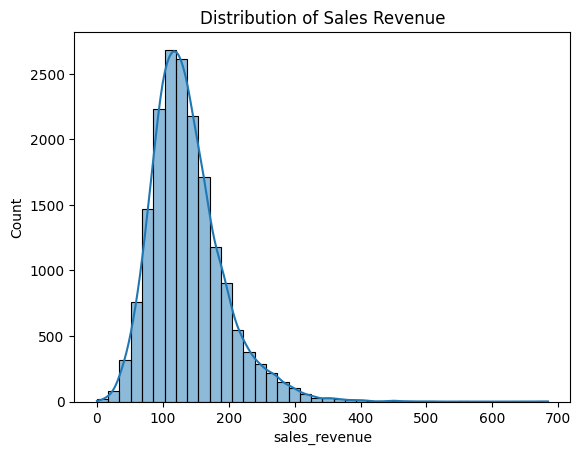

In [22]:
# distribution of sales revenue

sns.histplot(train['sales_revenue'], kde=True, bins=40)
plt.title('Distribution of Sales Revenue')

# skweness
train['sales_revenue'].skew()

In [23]:
cat_cols

Index(['region', 'channel', 'product_category', 'customer_segment'], dtype='object')

Text(0.5, 1.0, 'Region wise Sales Revenue')

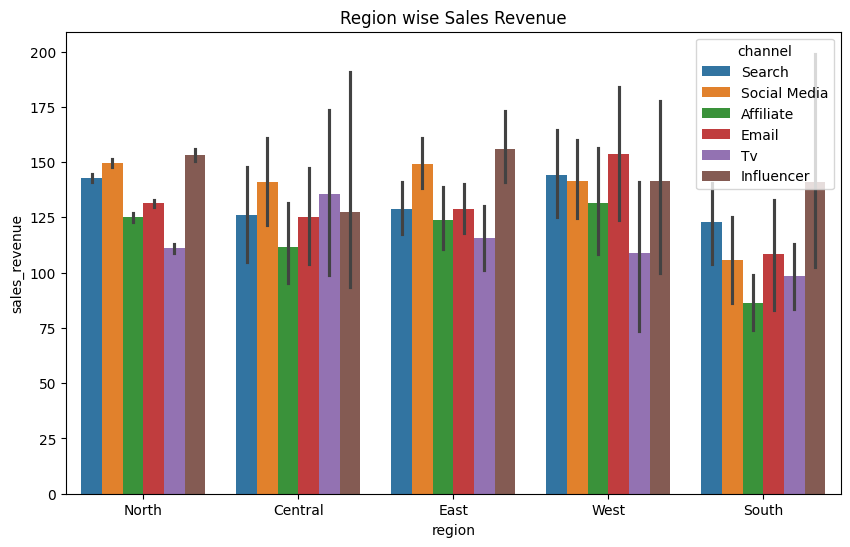

In [24]:
# region vs sales revenue

plt.figure(figsize=(10,6))
sns.barplot(x='region', y='sales_revenue', data = train, hue='channel')
plt.title('Region wise Sales Revenue')

Text(0.5, 1.0, 'Product Category impact on Sales Revenue')

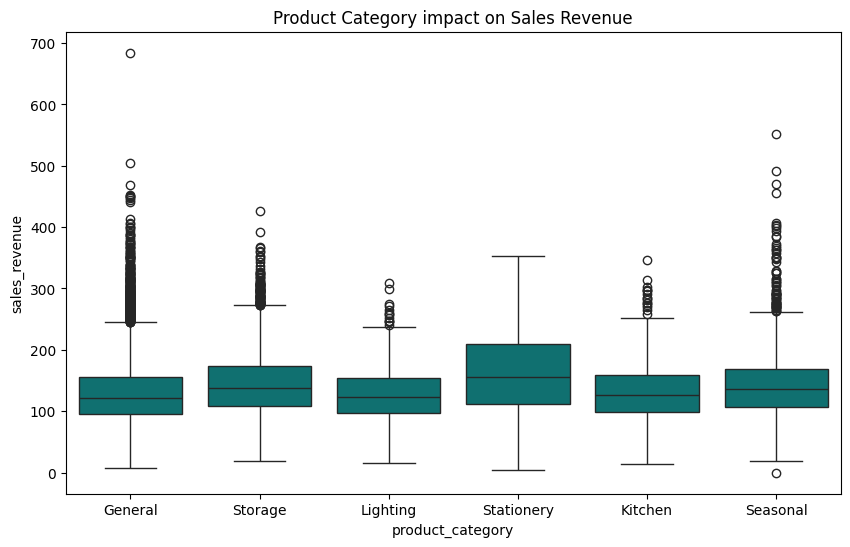

In [25]:
# product category vs sales revenue

plt.figure(figsize=(10,6))
sns.boxplot(x='product_category', y='sales_revenue', data= train, color= 'teal')
plt.title('Product Category impact on Sales Revenue')

Text(0.5, 1.0, 'Sales Generated by Marketing Channels')

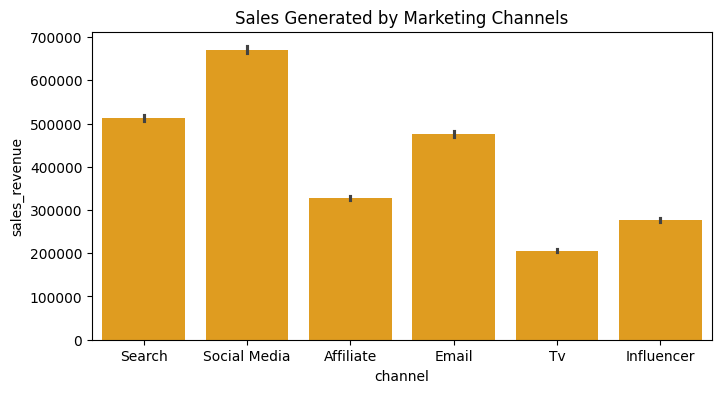

In [26]:
# channel vs sales revenue

plt.figure(figsize=(8,4))
sns.barplot(x='channel', y='sales_revenue', data=train, estimator=sum, color='orange')
plt.title('Sales Generated by Marketing Channels')

Text(0.5, 1.0, 'Channel impact on Sales Revenue')

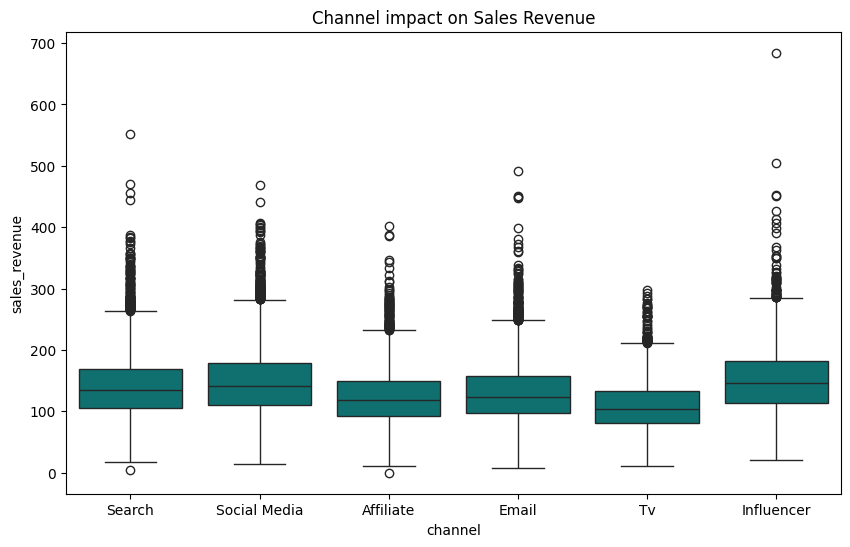

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(x='channel', y='sales_revenue', data= train, color= 'teal')
plt.title('Channel impact on Sales Revenue')

Text(0.5, 1.0, 'Impact of Customer Segment on Sales Revenue')

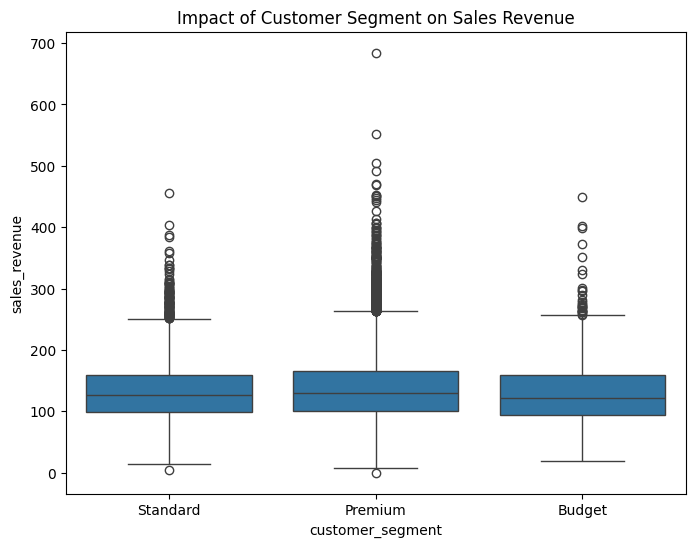

In [28]:
# Customer Segment vs Sales Revenue

plt.figure(figsize=(8,6))
sns.boxplot(x='customer_segment', y='sales_revenue', data=train)
plt.title('Impact of Customer Segment on Sales Revenue')

In [29]:
num_cols

Index(['id', 'ad_spend', 'price', 'discount_rate', 'market_reach',
       'impressions', 'click_through_rate', 'competition_index',
       'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

Text(0.5, 1.0, 'Customer Lifetime vs Sales Revenue')

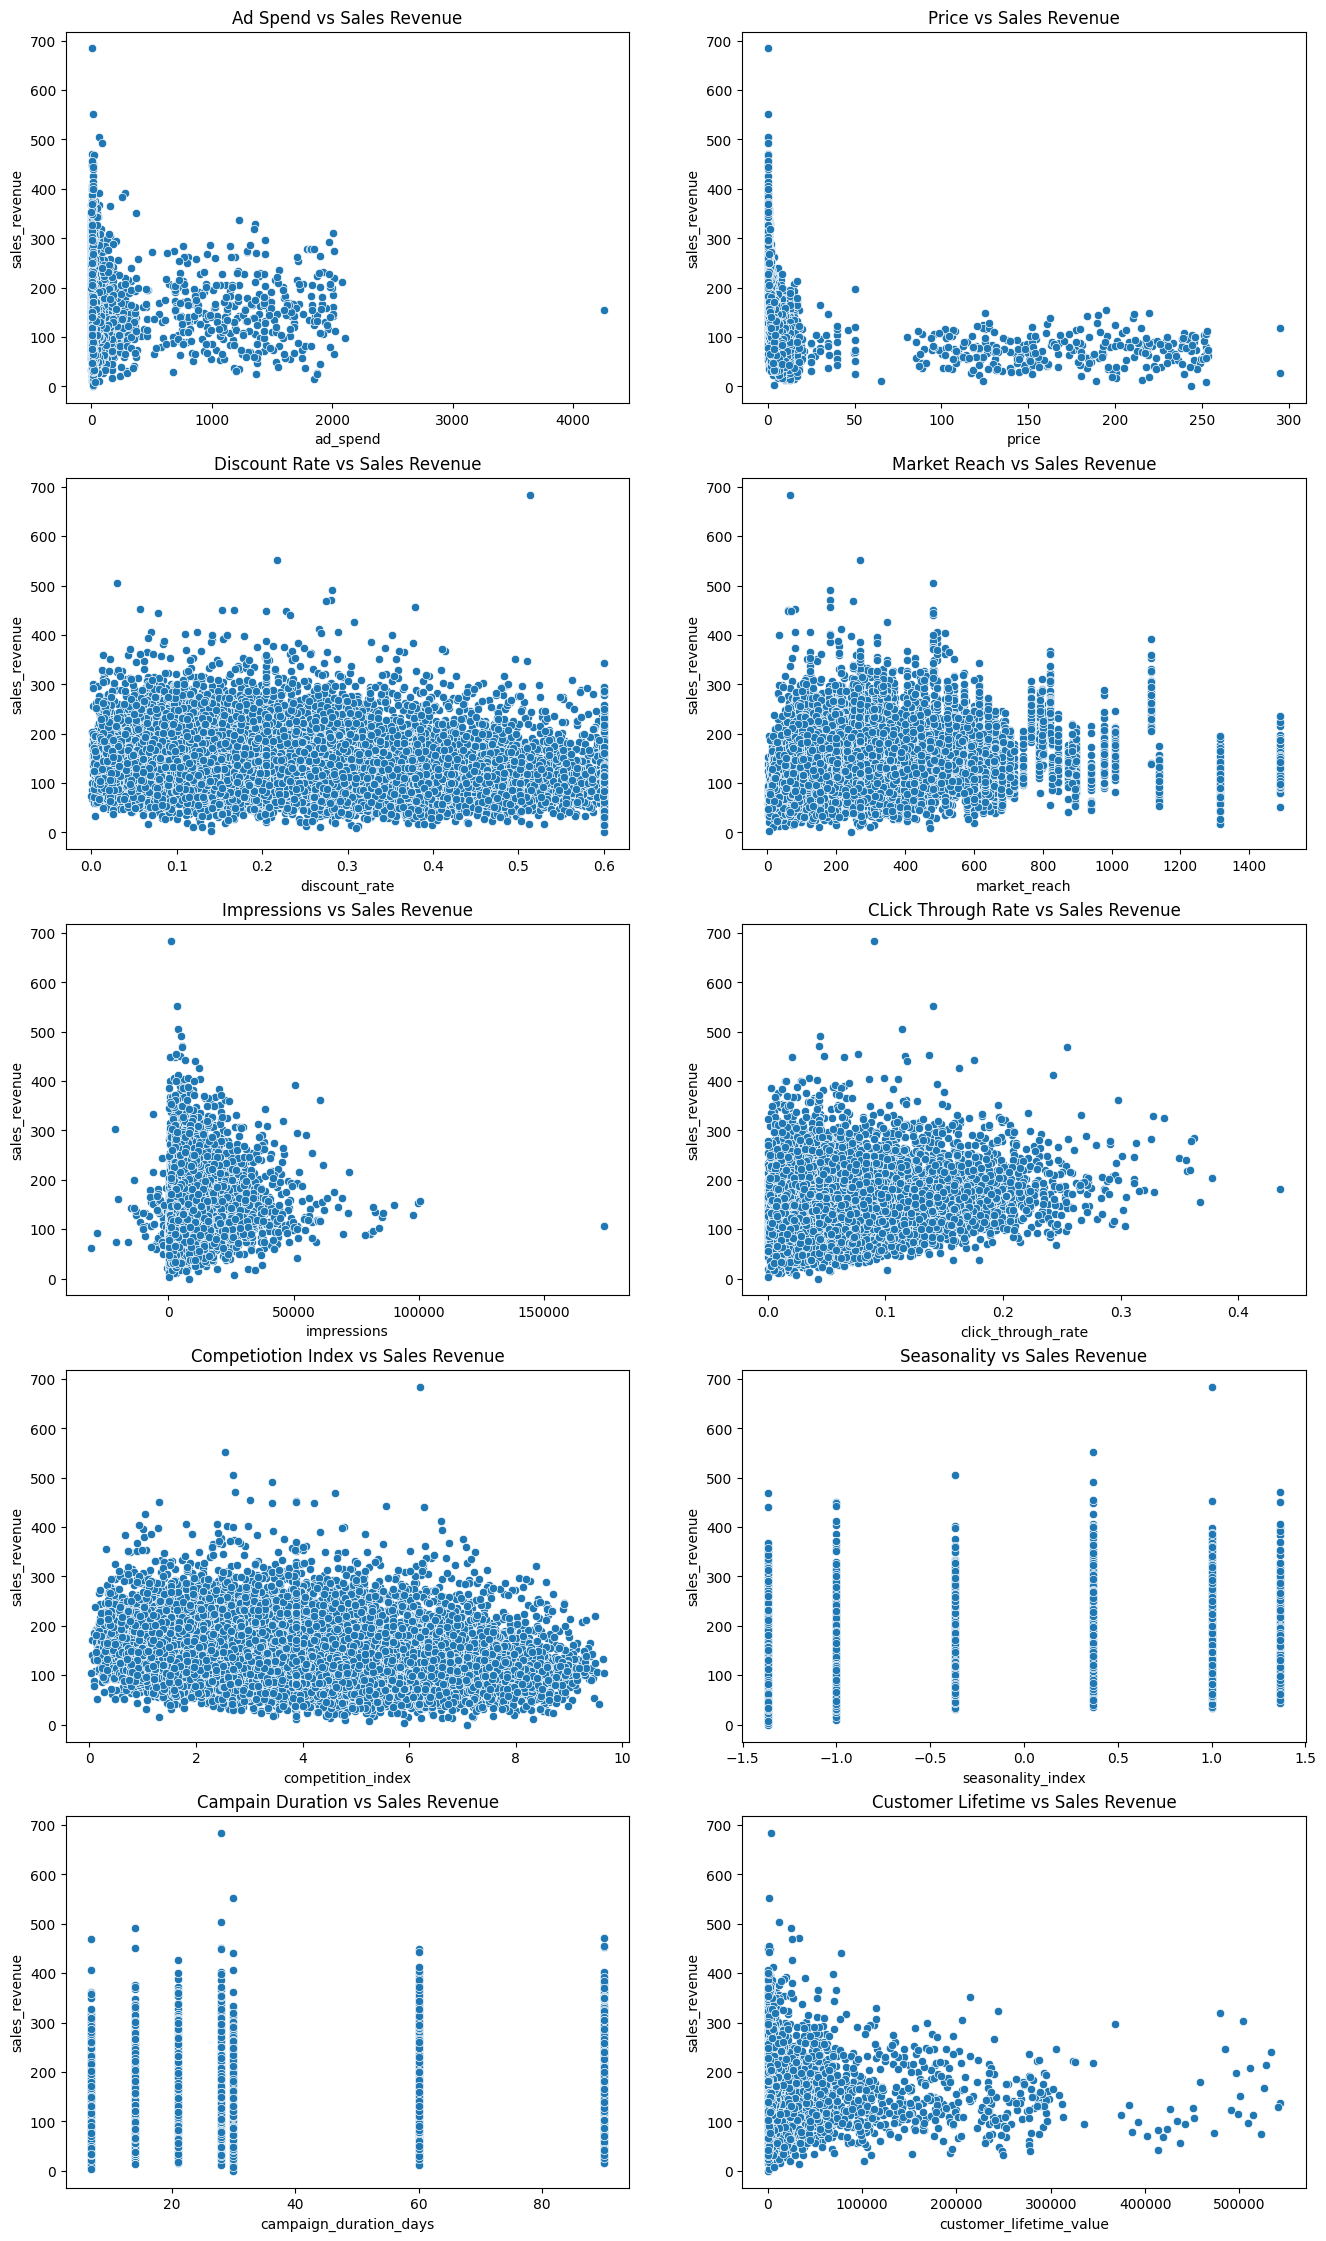

In [30]:
plt.figure(figsize=(16,28))

# Ad Spend vs Sales Revenue
plt.subplot(5,2,1)
sns.scatterplot(x='ad_spend', y='sales_revenue', data=train)
plt.title('Ad Spend vs Sales Revenue')

# Price vs Sales Revenue
plt.subplot(5,2,2)
sns.scatterplot(x='price', y='sales_revenue', data=train)
plt.title('Price vs Sales Revenue')

# Discount Rate vs Sales Revenue
plt.subplot(5,2,3)
sns.scatterplot(x='discount_rate', y='sales_revenue', data=train)
plt.title('Discount Rate vs Sales Revenue')

# market_reach vs Sales Revenue
plt.subplot(5,2,4)
sns.scatterplot(x='market_reach', y='sales_revenue', data=train)
plt.title('Market Reach vs Sales Revenue')

# impressions
plt.subplot(5,2,5)
sns.scatterplot(x='impressions', y='sales_revenue', data=train)
plt.title('Impressions vs Sales Revenue')

# Click through rate vs Sales Revenue
plt.subplot(5,2,6)
sns.scatterplot(x='click_through_rate', y='sales_revenue', data=train)
plt.title('CLick Through Rate vs Sales Revenue')

# competition_index vs Sales Revenue
plt.subplot(5,2,7)
sns.scatterplot(x='competition_index', y='sales_revenue', data=train)
plt.title('Competiotion Index vs Sales Revenue')

# Seasonality vs Sales revenue
plt.subplot(5,2,8)
sns.scatterplot(x='seasonality_index', y='sales_revenue', data=train)
plt.title('Seasonality vs Sales Revenue')

# Campain Duration Days
plt.subplot(5,2,9)
sns.scatterplot(x='campaign_duration_days', y='sales_revenue', data=train)
plt.title('Campain Duration vs Sales Revenue')

# Customer Lifetime Value
plt.subplot(5,2,10)
sns.scatterplot(x='customer_lifetime_value', y='sales_revenue', data=train)
plt.title('Customer Lifetime vs Sales Revenue')

### Correltaion

Text(0.5, 1.0, ' Correlation Heatmap of Numerical Marketing Metrics')

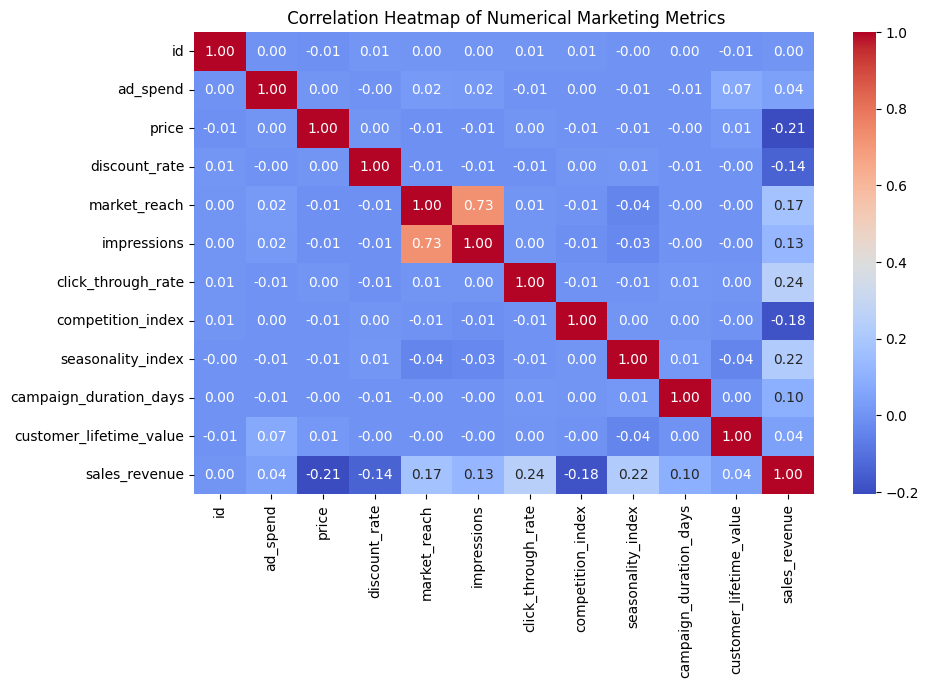

In [31]:
fig = plt.figure(figsize=(10,6))

corr = train.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(' Correlation Heatmap of Numerical Marketing Metrics')


## Model Training

In [32]:
pip install scikit learn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scikit (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for scikit


In [33]:
# importing required things

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [34]:
x = train.drop(columns=['id', 'date', 'ad_spend','competition_index','customer_lifetime_value', 'sales_revenue'], axis=1)

y = train['sales_revenue']

In [35]:
# splitting the dataset

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [36]:
# Numerical & Categorical data Encoding

num_ftrs = x_train.select_dtypes(include=['int64','float64']).columns
cat_ftrs = x_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_ftrs),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_ftrs)
    ]
)

### Linear Regression Model

In [37]:
# building pipeline

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('lr', LinearRegression())
])

In [38]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [39]:
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [40]:
y_pred

array([173.14916716, 129.33559269, 155.27814113, ...,  85.31043477,
       142.87812235, 174.17224258], shape=(3600,))

In [41]:
score = r2_score(y_test, y_pred)
score

0.2682496379170255

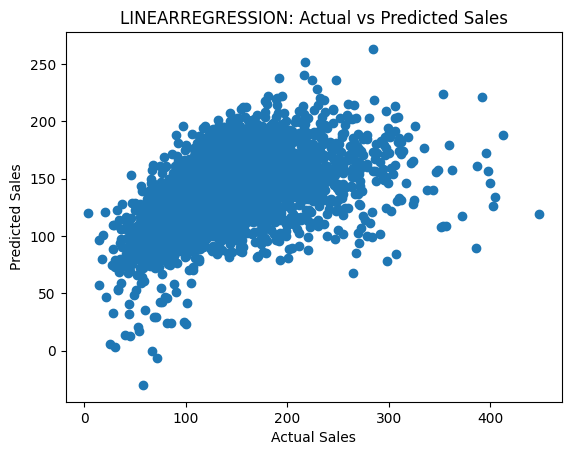

In [42]:
# plotting actual values & predicted values fro LinearRegression

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("LINEARREGRESSION: Actual vs Predicted Sales")
plt.show()

### Random Forest Regressor Model

In [43]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('rf', RandomForestRegressor())
])

pipeline.fit(x_train, y_train)

y_pred_rf = pipeline.predict(x_test)
y_pred_rf

score_rf = r2_score(y_test, y_pred_rf)
score_rf

0.8757637195509294

In [44]:
# error in actual & predicted values
mean_squared_error(y_test, y_pred_rf)

387.49135881823696

In [45]:
# applying cross validation  

scores = cross_val_score(pipeline, x, y, cv=5, scoring='r2')
print(scores.mean())

0.8741823695568198


In [46]:
print("Train R2:", pipeline.score(x_train, y_train))
print("Test R2:", pipeline.score(x_test, y_test))

Train R2: 0.9822559323565263
Test R2: 0.8757637195509294


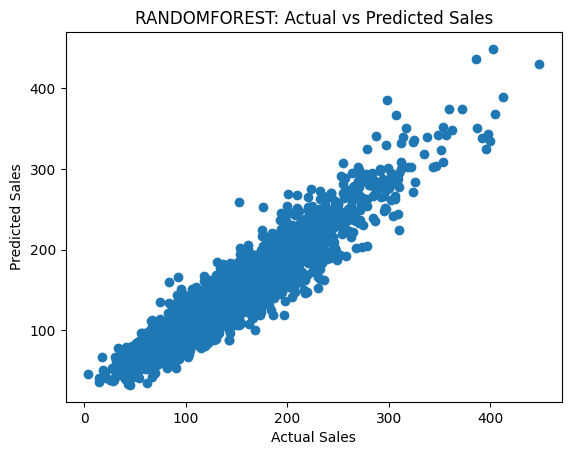

In [47]:
# plotting actual values & predicted values

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("RANDOMFOREST: Actual vs Predicted Sales")
plt.show()

### Xtreme Gradient Boost (XGBRegressor) Model

In [48]:
from xgboost import XGBRegressor

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('xg', XGBRegressor())
])

pipeline.fit(x_train, y_train)

y_pred_xg = pipeline.predict(x_test)
y_pred_xg

score_xg = r2_score(y_test, y_pred_xg)
score_xg

0.8922782380567014

In [49]:
mse_xg = mean_squared_error(y_test, y_pred_xg)
mse_xg

335.9827882710543

In [50]:
print('Train R2:', pipeline.score(x_train, y_train))

print('Test R2:', pipeline.score(x_test, y_test))

Train R2: 0.9501383559228047
Test R2: 0.8922782380567014


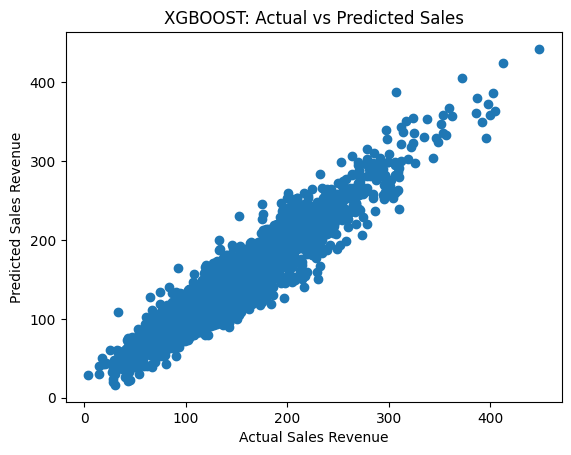

In [51]:
# plotting actual values & predicted values

plt.scatter(y_test, y_pred_xg)
plt.xlabel("Actual Sales Revenue")
plt.ylabel("Predicted Sales Revenue")
plt.title("XGBOOST: Actual vs Predicted Sales")
plt.show()

## Fine Tune the XGBOOST 

In [52]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# Note the 'xg__' prefix: this tells the pipeline to apply these to the 'xg' step
param_grid = {
    'xg__n_estimators': [100, 200,300,500,1000],           # Number of trees
    'xg__max_depth': [3, 5, 7,10],               # Depth of trees
    'xg__learning_rate': [0.01, 0.05, 0.1, 0.2],    # Step size shrinkage
    'xg__subsample': [0.8, 1.0]               # Percentage of data used per tree
}

# 2. Set up GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)

# 3. Fit the grid search to your training data
grid_search.fit(x_train, y_train)

# 4. Get the results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R2 Score: {grid_search.best_score_}")

# 5. Use the best model to predict
best_pipeline = grid_search.best_estimator_
y_pred_tuned = best_pipeline.predict(x_test)

final_score = r2_score(y_test, y_pred_tuned)
print(f"Final Tuned Test R2: {final_score}")


Best Parameters: {'xg__learning_rate': 0.05, 'xg__max_depth': 3, 'xg__n_estimators': 1000, 'xg__subsample': 0.8}
Best R2 Score: 0.9038111684455676
Final Tuned Test R2: 0.9078798014133586


In [80]:
best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('xg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [81]:
pipeline.fit(x, y)
predictions = best_pipeline.predict(test)
predictions

array([187.3539  , 145.96808 ,  98.374146, ..., 106.23719 , 161.53458 ,
        83.70228 ], shape=(6000,), dtype=float32)

In [82]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_pipeline, x, y, cv=5, scoring='r2')
print(scores.mean())

0.9048914261994924


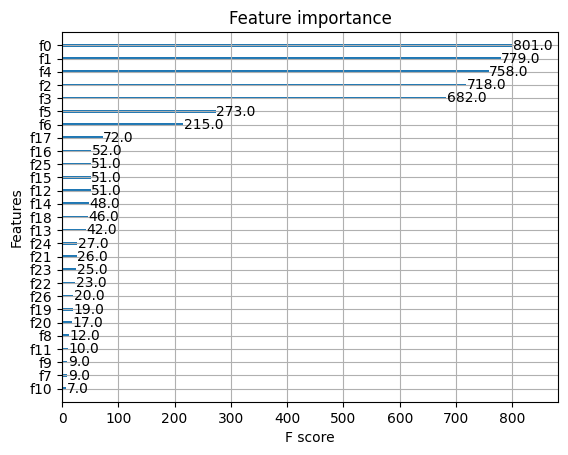

In [55]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Access the model inside the pipeline

model = pipeline.named_steps['xg']

# Now plot using the extracted model
plot_importance(model)
plt.show()

### Export Data for Dashboard

In [69]:
final_df = train.copy()

In [70]:
final_df['predicted_sales_revenue'] = pipeline.predict(x)

final_df.to_csv("final_dashboard_data.csv", index=False)

In [73]:
final_df.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue,predicted_sales_revenue
0,1,2011-12-05 11:31:00,North,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811,117.265099
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661,139.462524
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747,137.708115
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756,138.702744
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924,129.560944


In [67]:
# Check the correlation 
print(final_df[['sales_revenue', 'predicted_sales_revenue']].corr())

# Check top 5 errors to see if they are consistent
final_df['abs_error'] = abs(final_df['sales_revenue'] - final_df['predicted_sales_revenue'])
print(final_df.nlargest(5, 'abs_error'))

                         sales_revenue  predicted_sales_revenue
sales_revenue                 1.000000                 0.972781
predicted_sales_revenue       0.972781                 1.000000
          id                date region     channel product_category  \
16580  16581 2010-11-28 14:15:00  North   Affiliate         Seasonal   
6333    6334 2010-01-26 12:23:00  North       Email          Kitchen   
10144  10145 2010-11-15 09:02:00  North  Influencer         Seasonal   
16495  16496 2010-03-04 10:29:00  North       Email         Seasonal   
9448    9449 2010-12-07 16:43:00  North  Influencer         Seasonal   

      customer_segment     ad_spend  price  discount_rate  market_reach  \
16580          Premium  1890.574621   1.65         0.2562         329.0   
6333           Premium  1707.863339   1.25         0.1610         243.0   
10144          Premium  1821.660057   0.85         0.1308         247.0   
16495          Premium   934.371012   1.25         0.2228         391.0   


In [75]:
# Generate final predictions for the unseen test data
test_predictions = best_pipeline.predict(test)

# Create the submission or dashboard file for future dates
test['predicted_revenue'] = test_predictions
test.to_csv("future_revenue_projections.csv", index=False)